# Barren Plateaus and Quantum Optimization Simulation

## Table of Contents
1. [Summary](#Summary)
2. [Global configuration and dependencies](#Global-configuration-and-dependencies)
3. [Barren Plateaus](#Barren-Plateaus)
4. [Local COBYLA optimizer (4 qubits)](#Local-COBYLA-optimizer-4-qubits)
5. [COBYLA vs QNSPSA with early stopping (16 qubits)](#COBYLA-vs-QNSPSA-with-early-stopping-16-qubits)
6. [High dimensionality (6 qubits, 4 layers)](#High-dimensionality-6-qubits-4-layers)
7. [Shot noise (12 qubits)](#Shot-noise-12-qubits)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.optimizers import COBYLA, QNSPSA
import time

# Visual configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

## Barren Plateaus

In [ ]:
qubit_list = [2, 4, 6, 8, 10]  # Circuit sizes to evaluate
num_samples = 150              # Number of random parameter samples


In [ ]:
estimator = StatevectorEstimator()
variances = []  # Store computed variances

print("Starting Barren Plateau simulation...")
start_total = time.time()

# 2. Loop over qubit counts
for n in qubit_list:
    start_q = time.time()

    # Build the hardware-efficient ansatz
    # reps=3 provides depth, entanglement='full' maximizes expressivity
    ansatz = EfficientSU2(num_qubits=n, reps=3, entanglement='full')
    num_params = ansatz.num_parameters

    # Define global cost function (Z on all qubits)
    observable = SparsePauliOp.from_list([("Z" * n, 1)])

    gradients_theta_0 = []

    # 3. Statistical sampling (evaluate multiple random initializations)
    for _ in range(num_samples):
        # Random uniform initialization in [-pi, pi]
        params = np.random.uniform(-np.pi, np.pi, num_params)

        # Prepare shifted parameters for the parameter-shift rule on theta_0
        params_plus = params.copy()
        params_minus = params.copy()

        params_plus[0] += np.pi / 2
        params_minus[0] -= np.pi / 2

        # Run the circuit with both shifted parameter sets
        # pub (Primitive Unified Bloc): (circuit, observable, parameter_values)
        pub = (ansatz, observable, [params_plus, params_minus])
        job = estimator.run([pub])
        result = job.result()[0]

        # Retrieve expectation values
        ev_plus = result.data.evs[0]
        ev_minus = result.data.evs[1]

        # Compute exact gradient w.r.t. theta_0
        grad = 0.5 * (ev_plus - ev_minus)
        gradients_theta_0.append(grad)

    # 4. Variance calculation
    variance = np.var(gradients_theta_0)
    variances.append(variance)

    end_q = time.time()
    print(f"Qubits: {n} | Parameters: {num_params} | Variance: {variance:.8f} | Time: {end_q - start_q:.2f} s")

print(f"\nExperiment finished in {time.time() - start_total:.2f} seconds.")

Iniciando la simulación de Barren Plateaus...


/tmp/ipykernel_19684/212314810.py:13: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n, reps=3, entanglement='full')


Qubits: 2 | Parámetros: 16 | Varianza: 0.14191627 | Tiempo: 0.75 s
Qubits: 4 | Parámetros: 32 | Varianza: 0.03046986 | Tiempo: 1.42 s
Qubits: 6 | Parámetros: 48 | Varianza: 0.00642923 | Tiempo: 2.16 s
Qubits: 8 | Parámetros: 64 | Varianza: 0.00167540 | Tiempo: 3.01 s
Qubits: 10 | Parámetros: 80 | Varianza: 0.00041079 | Tiempo: 5.56 s

Experimento completado en 12.90 segundos.


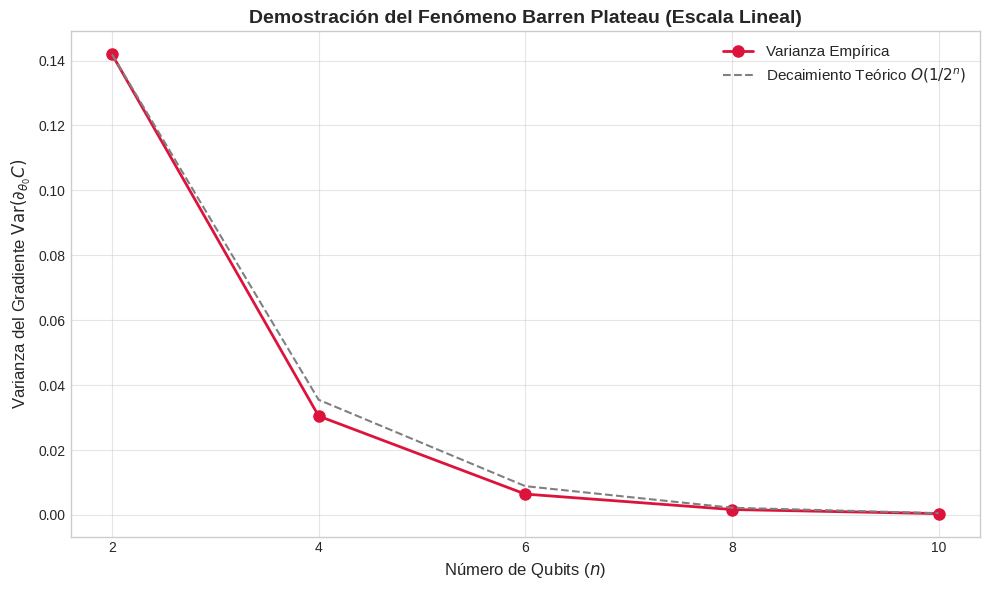

In [ ]:
plt.figure(figsize=(10, 6))

# Plot the empirical variance on linear scale
plt.plot(qubit_list, variances, 'o-', color='crimson', linewidth=2, markersize=8, label='Empirical Variance')

# Plot the theoretical reference line O(1/2^n)
ref_line = [variances[0] * (2 ** (qubit_list[0] - n)) for n in qubit_list]
plt.plot(qubit_list, ref_line, '--', color='gray', label='Theoretical decay $O(1/2^n)$')

plt.title('Barren Plateau Demonstration (Linear Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Qubits ($n$)', fontsize=12)
plt.ylabel('Gradient Variance $\\text{Var}(\\partial_{\\theta_0} C)$', fontsize=12)
plt.xticks(qubit_list)
plt.grid(True, ls='-', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Optimizer

/tmp/ipykernel_12323/132130956.py:12: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=1, entanglement='linear')


Iniciando entrenamiento con COBYLA (16 parámetros)...
Entrenamiento completado.
Valor mínimo alcanzado: -1.0000


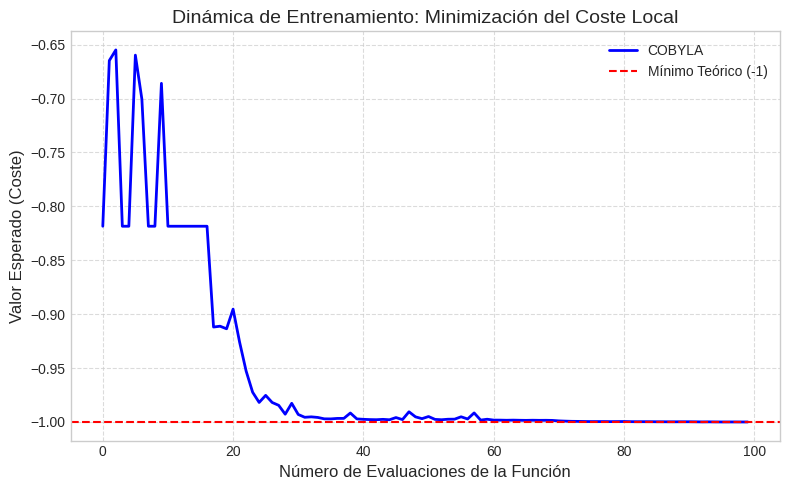

In [ ]:
# Global imports are already loaded in the configuration section.

# 1. Quantum system setup
n_qubits = 4
# We use low depth (reps=1) and linear entanglement to avoid barren plateaus and keep COBYLA stable.
ansatz = EfficientSU2(num_qubits=n_qubits, reps=1, entanglement='linear')
num_params = ansatz.num_parameters

# Local cost function (measure Z on qubit 0 only)
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
estimator = StatevectorEstimator()

# 2. Variable to store training history
cobyla_cost_history = []

# 3. Objective function
def objective_function(parameters):
    # Evaluate the circuit at current parameters
    pub = (ansatz, observable, [parameters])
    result = estimator.run([pub]).result()[0]
    cost = result.data.evs[0]

    # Save value for plotting
    cobyla_cost_history.append(cost)
    return cost

# 4. Optimizer initialization and execution
print(f"Starting training with COBYLA ({num_params} parameters)...")

# Random initialization in [-pi, pi]
initial_parameters = np.random.uniform(-np.pi, np.pi, num_params)

# Instantiate COBYLA with a maximum of 100 iterations
optimizer = COBYLA(maxiter=100)

# Execute minimization
result_cobyla = optimizer.minimize(fun=objective_function, x0=initial_parameters)

print("Training completed.")
print(f"Minimum value reached: {result_cobyla.fun:.4f}")

# 5. Results visualization
plt.figure(figsize=(8, 5))
plt.plot(cobyla_cost_history, label='COBYLA', color='blue', linewidth=2)
plt.axhline(y=-1.0, color='r', linestyle='--', label='Theoretical minimum (-1)')

plt.title('Training Dynamics: Local Cost Minimization', fontsize=14)
plt.xlabel('Function Evaluation Count', fontsize=12)
plt.ylabel('Expected Value (Cost)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19684/1860084545.py:14: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=1, entanglement='linear')


Ejecutando COBYLA (16 qubits)...
-> COBYLA detenido anticipadamente en la evaluación 278.
Ejecutando QNSPSA (16 qubits)...
-> QNSPSA detenido anticipadamente en la evaluación 770.


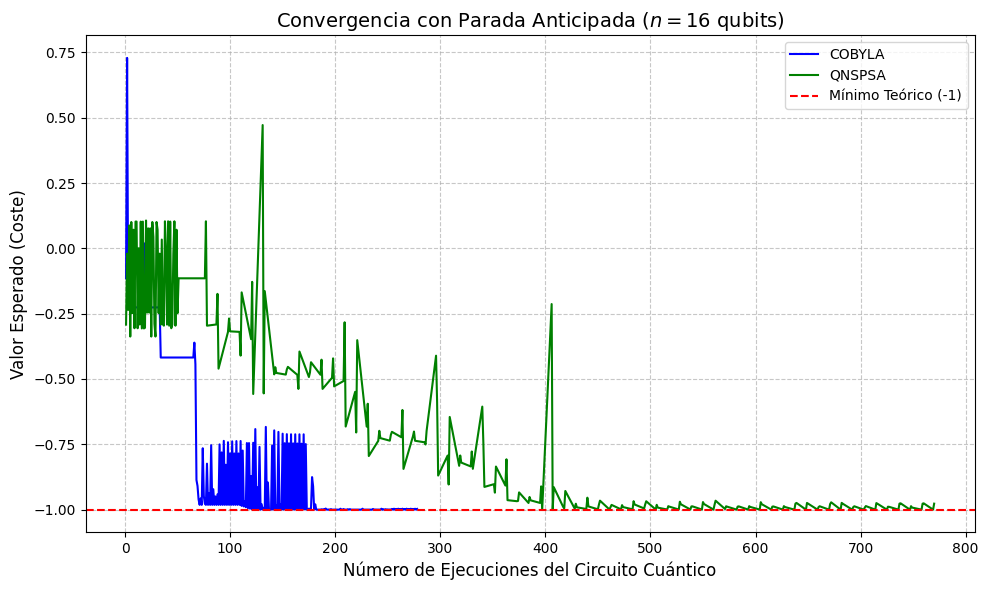

In [ ]:
# COBYLA vs QNSPSA with early stopping (16 qubits)
# Global imports are already loaded in the configuration section.

# 1. Custom exception definition
class ConvergenceReached(Exception):
    pass

# 2. System setup
n_qubits = 16
ansatz = EfficientSU2(num_qubits=n_qubits, reps=1, entanglement='linear')
observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
estimator = StatevectorEstimator()
num_params = ansatz.num_parameters
p0 = np.random.uniform(-np.pi, np.pi, num_params)

# 3. Early stopping parameters
WINDOW_EVALS = 100
TOLERANCE = 1e-1

# 4. Containers and evaluation functions
history_cobyla = {'evals': [], 'cost': []}
history_qnspsa = {'evals': [], 'cost': []}

cobyla_eval_count = 0
def objective_function_cobyla(parameters):
    global cobyla_eval_count
    cobyla_eval_count += 1

    pub = (ansatz, observable, [parameters])
    cost = estimator.run([pub]).result()[0].data.evs[0]

    history_cobyla['evals'].append(cobyla_eval_count)
    history_cobyla['cost'].append(cost)

    # Early stopping check
    if len(history_cobyla['cost']) >= WINDOW_EVALS:
        last_window = history_cobyla['cost'][-WINDOW_EVALS:]
        variation = max(last_window) - min(last_window)
        if variation < TOLERANCE:
            raise ConvergenceReached()

    return cost

qnspsa_eval_count = 0
def objective_function_qnspsa(parameters):
    global qnspsa_eval_count
    qnspsa_eval_count += 1

    pub = (ansatz, observable, [parameters])
    cost = estimator.run([pub]).result()[0].data.evs[0]

    history_qnspsa['evals'].append(qnspsa_eval_count)
    history_qnspsa['cost'].append(cost)

    # Early stopping check
    if len(history_qnspsa['cost']) >= WINDOW_EVALS:
        last_window = history_qnspsa['cost'][-WINDOW_EVALS:]
        variation = max(last_window) - min(last_window)
        if variation < TOLERANCE:
            raise ConvergenceReached()

    return cost

def compute_fidelity(params1, params2):
    global qnspsa_eval_count
    qnspsa_eval_count += 2
    sv1 = Statevector(ansatz.assign_parameters(params1))
    sv2 = Statevector(ansatz.assign_parameters(params2))
    return np.abs(sv1.inner(sv2))**2

# 5. Execution with exception handling
print(f"Running COBYLA ({n_qubits} qubits)...")
opt_cobyla = COBYLA(maxiter=500)
try:
    opt_cobyla.minimize(fun=objective_function_cobyla, x0=p0)
except ConvergenceReached:
    print(f"-> COBYLA stopped early at evaluation {cobyla_eval_count}.")

print(f"Running QNSPSA ({n_qubits} qubits)...")
opt_qnspsa = QNSPSA(fidelity=compute_fidelity, maxiter=500)
try:
    opt_qnspsa.minimize(fun=objective_function_qnspsa, x0=p0)
except ConvergenceReached:
    print(f"-> QNSPSA stopped early at evaluation {qnspsa_eval_count}.")

# 6. Convergence plot
plt.figure(figsize=(10, 6))
plt.plot(history_cobyla['evals'], history_cobyla['cost'], label='COBYLA', color='blue')
plt.plot(history_qnspsa['evals'], history_qnspsa['cost'], label='QNSPSA', color='green')

plt.axhline(y=-1.0, color='r', linestyle='--', label='Theoretical minimum (-1)')
plt.title(f'Convergence with Early Stopping ($n={n_qubits}$ qubits)', fontsize=14)
plt.xlabel('Quantum Circuit Execution Count', fontsize=12)
plt.ylabel('Expected Value (Cost)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19684/585207901.py:11: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=capas, entanglement='linear')


Ejecutando COBYLA (Parámetros: 60)...
Ejecutando QNSPSA (Parámetros: 60)...


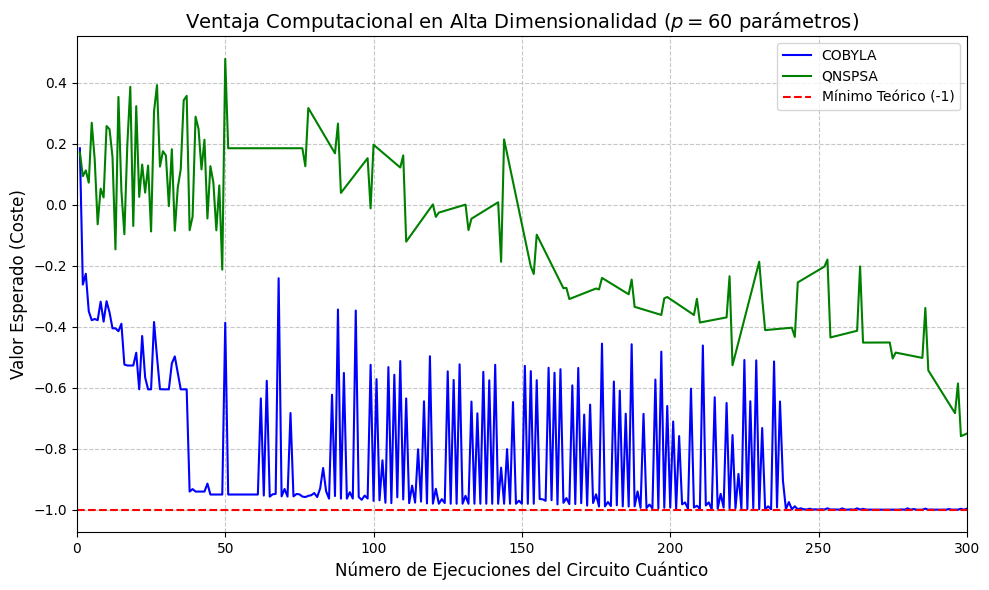

In [ ]:
# High dimensionality (6 qubits, 4 layers)
# Global imports are already loaded in the configuration section.

# 1. High-dimensionality system setup
n_qubits = 6
layers = 4
ansatz = EfficientSU2(num_qubits=n_qubits, reps=layers, entanglement='linear')
num_params = ansatz.num_parameters  # This will produce 60 parameters

observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])
estimator = StatevectorEstimator()

# Shared initialization for fair comparison
np.random.seed(42)  # Set seed for reproducibility
p0 = np.random.uniform(-np.pi, np.pi, num_params)

# 2. Containers and evaluation functions
history_cobyla = {'evals': [], 'cost': []}
history_qnspsa = {'evals': [], 'cost': []}

cobyla_eval_count = 0
def objective_function_cobyla(parameters):
    global cobyla_eval_count
    cobyla_eval_count += 1

    pub = (ansatz, observable, [parameters])
    cost = estimator.run([pub]).result()[0].data.evs[0]

    history_cobyla['evals'].append(cobyla_eval_count)
    history_cobyla['cost'].append(cost)
    return cost

qnspsa_eval_count = 0
def objective_function_qnspsa(parameters):
    global qnspsa_eval_count
    qnspsa_eval_count += 1

    pub = (ansatz, observable, [parameters])
    cost = estimator.run([pub]).result()[0].data.evs[0]

    history_qnspsa['evals'].append(qnspsa_eval_count)
    history_qnspsa['cost'].append(cost)
    return cost

def compute_fidelity(params1, params2):
    global qnspsa_eval_count
    # Add evaluations needed to compute state overlap
    qnspsa_eval_count += 2
    sv1 = Statevector(ansatz.assign_parameters(params1))
    sv2 = Statevector(ansatz.assign_parameters(params2))
    return np.abs(sv1.inner(sv2))**2

# 3. Optimizer execution (limited by iteration budget)
# COBYLA uses 'maxiter' as a function-evaluation cap in its SciPy backend.
print(f"Running COBYLA (Parameters: {num_params})...")
opt_cobyla = COBYLA(maxiter=300)
opt_cobyla.minimize(fun=objective_function_cobyla, x0=p0)

# QNSPSA uses 'maxiter' as actual update steps.
# We use fewer steps to approximately match the total evaluation budget.
print(f"Running QNSPSA (Parameters: {num_params})...")
opt_qnspsa = QNSPSA(fidelity=compute_fidelity, maxiter=50)
opt_qnspsa.minimize(fun=objective_function_qnspsa, x0=p0)

# 4. Convergence plot
plt.figure(figsize=(10, 6))
plt.plot(history_cobyla['evals'], history_cobyla['cost'], label='COBYLA', color='blue')
plt.plot(history_qnspsa['evals'], history_qnspsa['cost'], label='QNSPSA', color='green')

plt.axhline(y=-1.0, color='r', linestyle='--', label='Theoretical minimum (-1)')
plt.title(f'Computational Advantage in High Dimensionality ($p={num_params}$ parameters)', fontsize=14)
plt.xlabel('Quantum Circuit Execution Count', fontsize=12)
plt.ylabel('Expected Value (Cost)', fontsize=12)

# Limit the x-axis to 300 evaluations to compare equal budgets
plt.xlim(0, 300)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_19684/3888666491.py:11: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(num_qubits=n_qubits, reps=capas, entanglement='linear')


Ejecutando COBYLA con ruido estadístico (99 shots)...
Ejecutando QNSPSA con ruido estadístico (99 shots)...


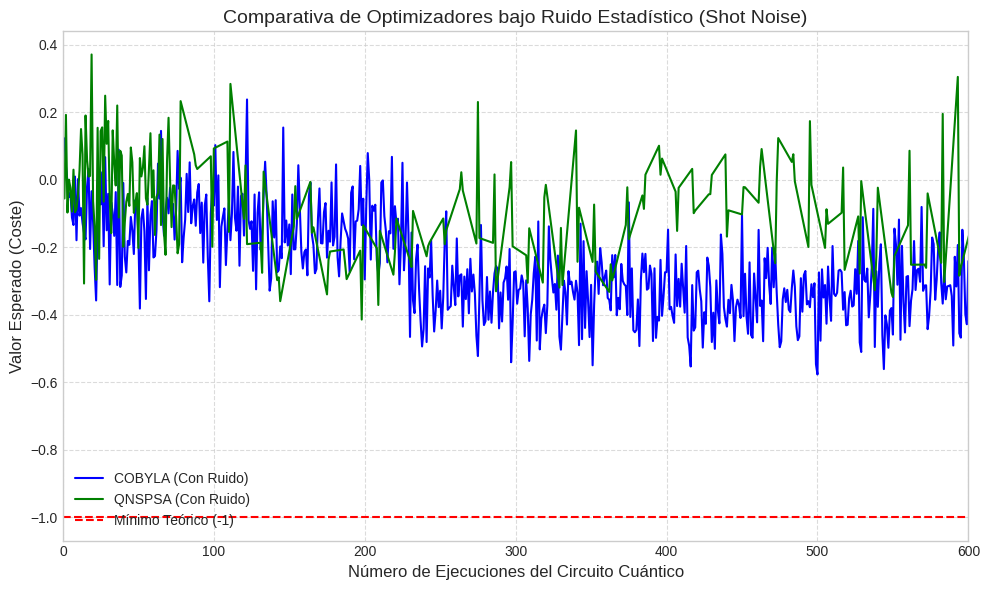

In [ ]:
# Shot noise (12 qubits)
# Global imports are already loaded in the configuration section.
from qiskit_aer.primitives import EstimatorV2
# Keep EstimatorV2 local to this section for the shot-noise experiment.

n_qubits = 12
layers = 8
ansatz = EfficientSU2(num_qubits=n_qubits, reps=layers, entanglement='linear')
num_params = ansatz.num_parameters

observable = SparsePauliOp.from_list([("I" * (n_qubits - 1) + "Z", 1)])

# 1. Circuit decomposition
# Create a decomposed version of the circuit with basic gates exposed
ansatz_decomposed = ansatz.decompose()

# Set target precision parameter
target_precision = 0.1

# Calculate shots by precision requirement and enforce integer count
num_shots = int(1 / (target_precision ** 2))

# Initialize estimator with the precision option
estimator = EstimatorV2(options={"default_precision": target_precision})

np.random.seed(42)
p0 = np.random.uniform(-np.pi, np.pi, num_params)

history_cobyla = {'evals': [], 'cost': []}
history_qnspsa = {'evals': [], 'cost': []}

cobyla_eval_count = 0
def objective_function_cobyla(parameters):
    global cobyla_eval_count
    cobyla_eval_count += 1

    # 2. Use decomposed circuit in the pub
    pub = (ansatz_decomposed, observable, [parameters])

    result = estimator.run([pub]).result()[0]
    cost = result.data.evs[0]

    history_cobyla['evals'].append(cobyla_eval_count)
    history_cobyla['cost'].append(cost)
    return cost

qnspsa_eval_count = 0
def objective_function_qnspsa(parameters):
    global qnspsa_eval_count
    qnspsa_eval_count += 1

    # 2. Use decomposed circuit in the pub
    pub = (ansatz_decomposed, observable, [parameters])

    result = estimator.run([pub]).result()[0]
    cost = result.data.evs[0]

    history_qnspsa['evals'].append(qnspsa_eval_count)
    history_qnspsa['cost'].append(cost)
    return cost

def compute_fidelity(params1, params2):
    global qnspsa_eval_count
    qnspsa_eval_count += 2
    # The pure statevector supports EfficientSU2, so ansatz_decomposed is optional.
    sv1 = Statevector(ansatz_decomposed.assign_parameters(params1))
    sv2 = Statevector(ansatz_decomposed.assign_parameters(params2))
    return np.abs(sv1.inner(sv2))**2

print(f"Running COBYLA with shot noise ({num_shots} shots)...")

MAX_ITER = 600

opt_cobyla = COBYLA(MAX_ITER)
opt_cobyla.minimize(fun=objective_function_cobyla, x0=p0)

print(f"Running QNSPSA with shot noise ({num_shots} shots)...")
opt_qnspsa = QNSPSA(fidelity=compute_fidelity, maxiter=50)
opt_qnspsa.minimize(fun=objective_function_qnspsa, x0=p0)

plt.figure(figsize=(10, 6))
plt.plot(history_cobyla['evals'], history_cobyla['cost'], label='COBYLA (With Noise)', color='blue')
plt.plot(history_qnspsa['evals'], history_qnspsa['cost'], label='QNSPSA (With Noise)', color='green')

plt.axhline(y=-1.0, color='r', linestyle='--', label='Theoretical minimum (-1)')
plt.title('Optimizer Comparison under Statistical Noise (Shot Noise)', fontsize=14)
plt.xlabel('Quantum Circuit Execution Count', fontsize=12)
plt.ylabel('Expected Value (Cost)', fontsize=12)
plt.xlim(0, MAX_ITER)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()